# LSST Data Preview 2 — LSDB tutorial

This tutorial demonstrates the use of LSDB to query the LSST Data Preview 2 catalog.

If you just want a minimal code example, see the **DP2 Starter** notebook.

Make sure you choose the **latest Weekly release** when you run this notebook on the RSP. This will give you the latest software versions with bug fixes and performance improvements.

## Setup

In [2]:
import lsdb

import astropy.units as u
from astropy.coordinates import SkyCoord
from upath import UPath
import matplotlib.pyplot as plt
from lsst.utils.plotting import (get_multiband_plot_colors,
                                 get_multiband_plot_symbols)

In [3]:
# Setup
from dask.distributed import Client
client = Client(n_workers=4, memory_limit="4GiB", threads_per_worker=1)

## Open catalog

In [4]:
# Open the LSST Object catalog
base_path = UPath("/rubin/lsdb_data")
cat = lsdb.open_catalog(base_path / "object_collection")
cat

### Note: Lazy evaluation

The catalog has been loaded *lazily*: no data has been read, only the catalog schema.

First we will filter the catalog down to only the data we need. Later, we will compute the catalog to download the data.

To learn more about lazy evaluation in LSDB, see the tutorial **Why Lazy Evaluation?**

## Choose columns

The Rubin catalog has 1304 data columns. We can choose only the columns we need for our analysis, which will speed up the compute step later.

All columns are listed on [data.lsdb.io](https://data.lsdb.io/Rubin_DP1/object_collection).

Let's take a look at the default columns.

In [5]:
cat.columns

We can choose columns using `lsdb.open_catalog(..., columns=columns)`. Note that `coord_ra` and `coord_dec` are always included.

In [6]:
cat = lsdb.open_catalog(base_path / "object_collection",
            columns=['z_psfFlux', 'z_psfFluxErr', 'z_psfModel_TwoGaussian_chisq_reduced'])
cat

Choosing only these columns cut down the size of the catalog from 9.6 GB to 82.8 MB — less than 1%.

For now, let's use the default columns.

In [7]:
cat = lsdb.open_catalog(base_path / "object_collection")

## Plot catalog

Using `cat.per_partition_statistics()`, we can see the number of objects per pixel:

In [11]:
plt.hist(cat.per_partition_statistics()[["objectId: row_count"]], bins=64);
plt.title("Number of objects per pixel")
plt.xlabel("Number of objects")
plt.ylabel("Number of pixels");

We can see the spatial density of the catalog with a sky plot:

In [12]:
cat.plot_pixels();

We can also zoom in to a region in the sky. Let's focus on the northernmost region, at (ra=38, dec=7). This is the Rubin SV Low Ecliptic Latitude Field.

In [13]:
import astropy.units as u
fov = (8 * u.deg, 8 * u.deg)
center = SkyCoord(38 * u.deg, 7 * u.deg)
fig, ax = cat.plot_pixels(projection="AIT", fov=fov, center=center);

We can visualize the angular density in the same region:

In [14]:
import hats
hats.inspection.plot_density(cat.hc_structure, ec='face', projection="AIT", fov=fov, center=center);

## Spatial filtering

Now let's restrict the catalog to the region where we zoomed in.

In [67]:
cat = lsdb.open_catalog(base_path / "object_collection", columns=columns,
    ).cone_search(ra=38.0, dec=7, radius_arcsec=2*3600)

Equivalent to this Catalog search in the [Portal](https://data.lsst.cloud/portal/app/):

<div>
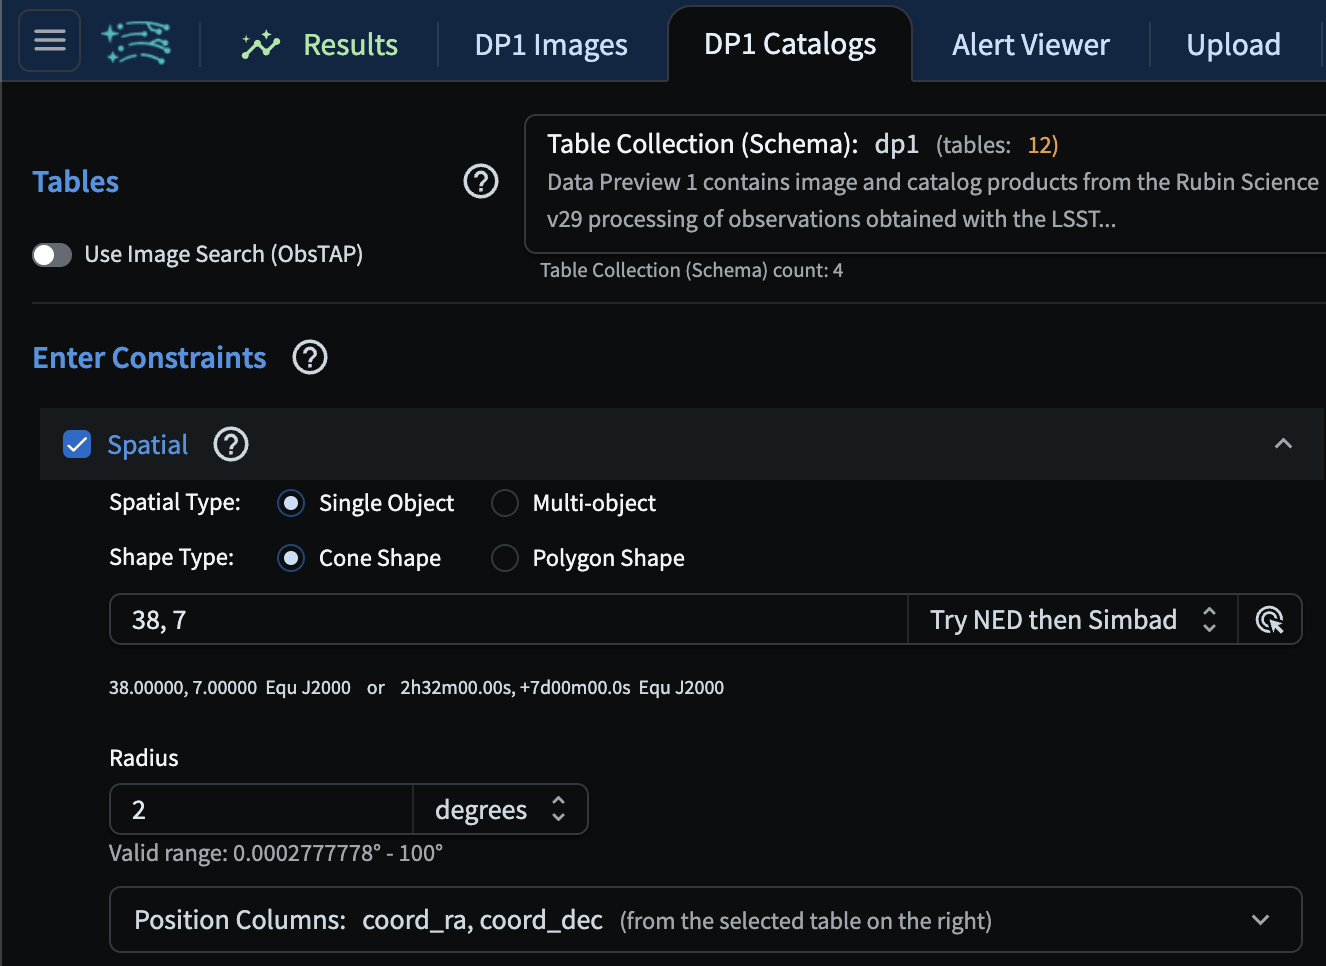
</div>

Result:

<div>
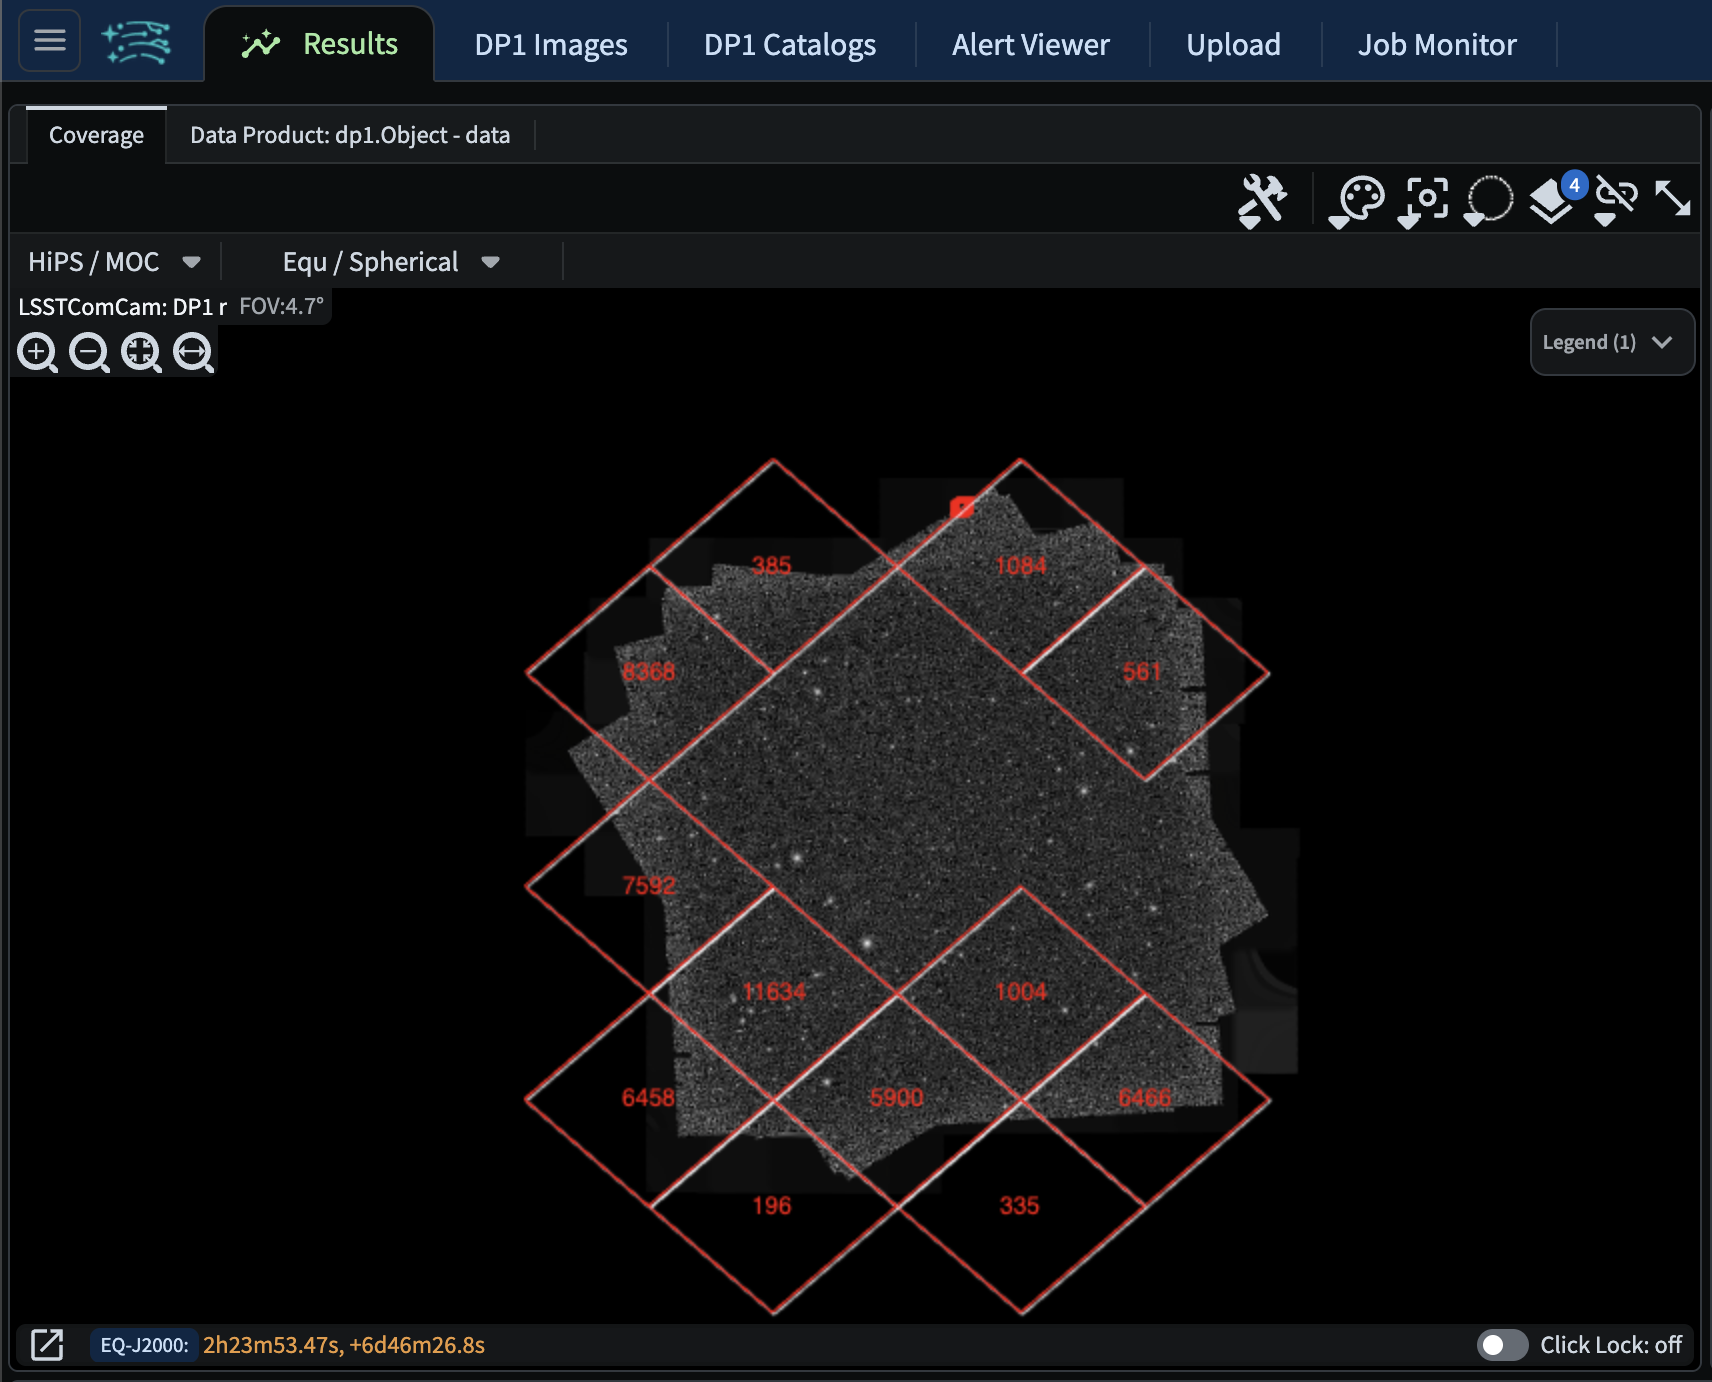
</div>
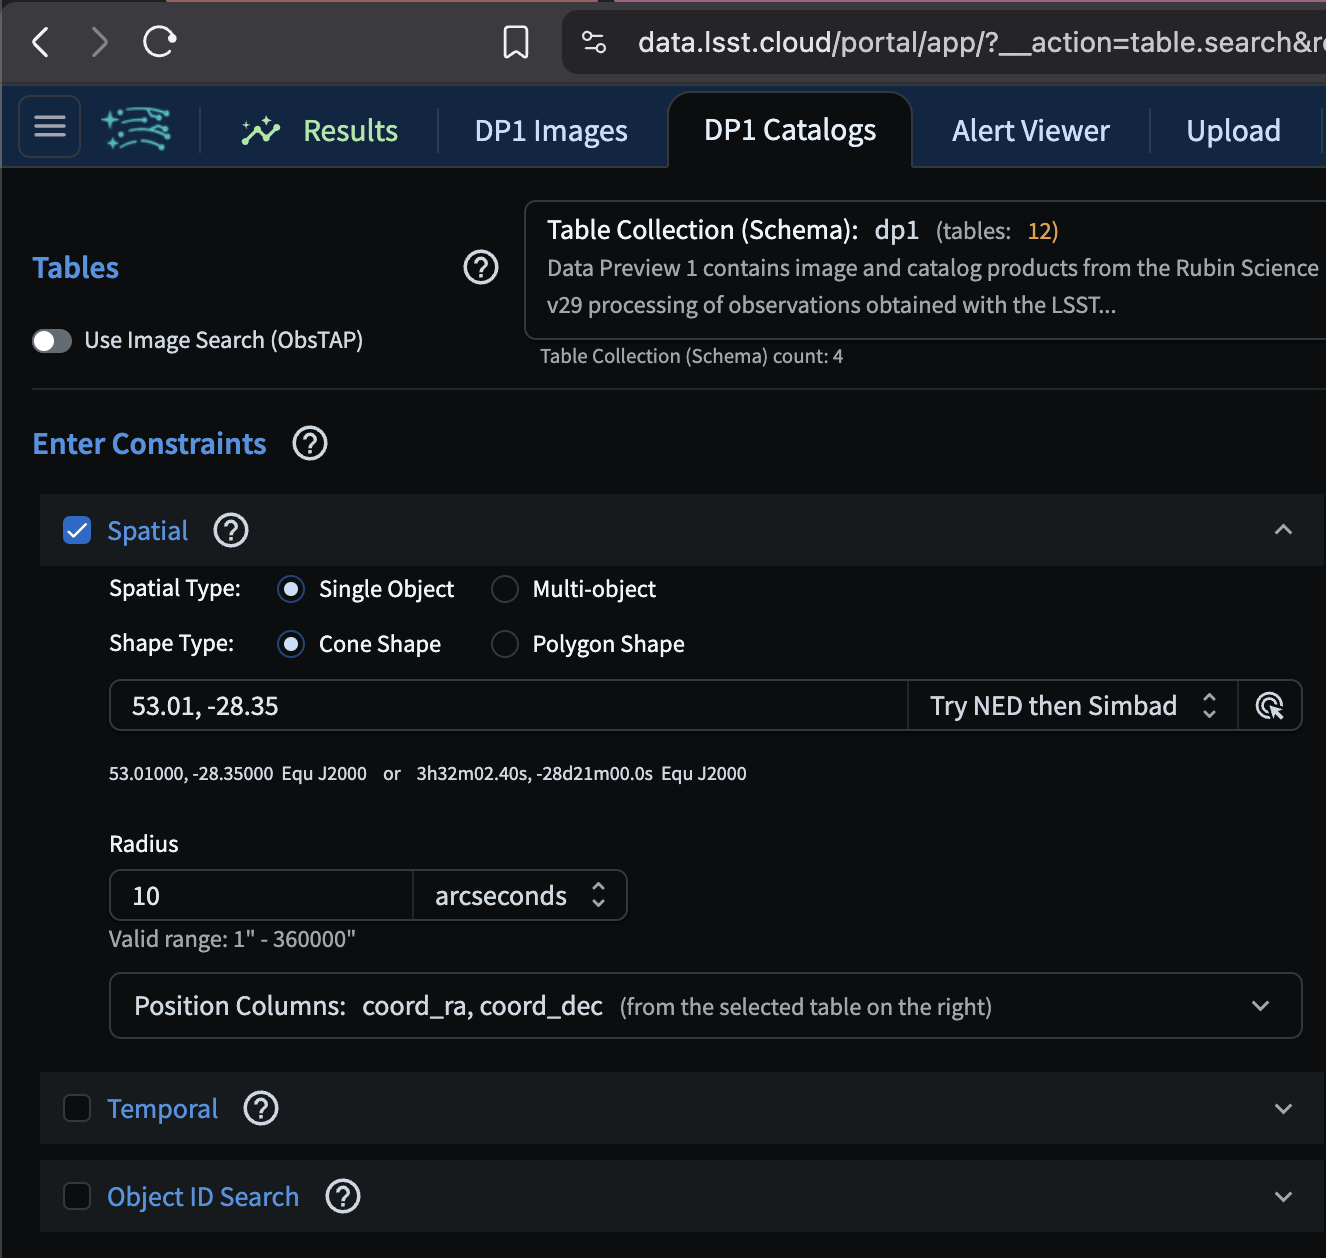

The filtered catalog is significantly smaller:

In [15]:
cat

In [45]:
# TODO how to plot_pixels() with a circle for the cone search

In [88]:
cat.head(5)

In [47]:
cat.random_sample(5, seed=808)

## Timing

### Open catalog and filter to a cone search
operation | time
----------|------
open_catalog() | < 3 s
cone_search() | < 1 s
cat | < 0.1 s

### Previewing a subset of the filtered catalog
operation | time
----------|------
head(5) | < 1 s
head(10) | < 1 s
head(50) | < 1 s
head(100) | < 1 s
random_sample(5) | < 30 s
random_sample(10) | < 32 s
random_sample(50) | < 35 s
random_sample(100) | < 40 s

### Querying by columns
operation | time
----------|------
query() | < 1 s

### Computing the filtered, queried catalog
operation | time
----------|------
compute() | < 30 s

Any time we compute the catalog, or get a subset, the result is a `nested_pandas.NestedFrame`, which is a kind of `pandas.DataFrame`.

In [49]:
df = cat.head(5)
print(type(df))
import pandas as pd
print(isinstance(df, pd.DataFrame))

# filter for color
use the existing rubin notebooks
e.g. select quasars, select giants (maybe, check their notebooks)

also dp1 vs gaia crossmatching

maybe wise infrared colors

maybe just do color g-r (mag) or g/r (flux)

Need to update the extendedness stuff to maybe sum and rank....

In [90]:
thresh = 0.5
query = f"u_extendedness < {thresh} or g_extendedness < {thresh} or r_extendedness < {thresh} or i_extendedness < {thresh} or z_extendedness < {thresh} or y_extendedness < {thresh}"
star_cat = cat.query(query)

In [91]:
star_df = star_cat.compute()

In [102]:
star_df[['g_extendedness', 'i_extendedness', 'z_extendedness']].value_counts()

In [78]:
query = "u_extendedness > 0.1 and g_extendedness > 0.1 and r_extendedness > 0.1 and i_extendedness > 0.1 and z_extendedness > 0.1 and y_extendedness > 0.1"
galaxy_cat = cat.query(query)

In [79]:
galaxy_df = galaxy_cat.compute()

In [81]:
galaxy_df

In [20]:
# TODO show multiple-condition query

In [21]:
# TODO show catalog writing

In [22]:
# TODO show catalog reading

In [23]:
# TODO show crossmatching